# 99_slot_effects — 슬롯 차원별 효과 라인플롯

각 슬롯 차원(q, prior, p, pw, om)이 성과에 미치는 효과를 시각화.

## 시각화 구조

각 차원별로 **1 figure × 3 subplots** (sharpe / sortino / mdd):
- **각 line = 1개 고정 조합** (예: omega 차원이면 `mcap_ls_eq_lam` 같은 prior+p+pw+q 조합)
- **x축** = 변수 차원의 값들 (예: omega면 he, pap, rms)
- **y축** = 메트릭 값
- **선 색깔** = 각 조합마다 고유색 (총 40~50개 line, 범례에 모두 표기)

→ 한 line을 따라가면 "이 조합에서 omega가 he→pap→rms로 바뀔 때 sortino가 어떻게 변하는가" 직접 확인.

## 사전 조건

[`99_analyze.ipynb`](99_analyze.ipynb)의 K_CUT 및 섹션 L (`all_slots_full_metrics.csv` 생성)을 먼저 실행. 이 노트북의 setup 셀이 pivot CSV 5개를 자동 생성한다 (sensitivity sweep 변형은 자동 제외).

## 추가 섹션
- **📍 논문 baseline 비교** (이 노트북 상단) — `mcap_tr_mcap_ff3_pap` anchor 기준 슬롯 효과 격자, ff3/none/capm 비교군까지 포함.
- **🟢 Winner anchor**: `eq_ls_eq_lam_pap` (K2-X50 composite Top 1, in-sample 168m) — q/prior/pw/om 셀에서 paper와 통합 비교.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

OUT_DIR  = Path.cwd() / 'outputs' / '99_analyze'
PLOT_DIR = OUT_DIR / 'slot_effects'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 차원별 x축 값 순서 (의미 있는 순서로)
DIM_VALUE_ORDERS = {
    'q'    : ['fix', 'lam', 'raw', 'inv', 'vsp'],   # none/capm/ff3 비교군 제외
    'prior': ['mcap', 'eq', 'rp'],
    'p'    : ['tr', 'ls'],
    'pw'   : ['mcap', 'eq', 'rp'],   # volm 제외
    'om'   : ['he', 'pap', 'rms'],
}

DIM_LABELS = {
    'q'    : 'q_mode',
    'prior': 'prior',
    'p'    : 'p_mode',
    'pw'   : 'p_weight',
    'om'   : 'omega_mode',
}

# ── Pivot CSV 생성 (이전엔 99_analyze L3 셀에서 만들었음 — 자기-완결성 위해 이 노트북으로 이동) ──
# 입력 : 99_analyze.ipynb 섹션 L에서 생성하는 all_slots_full_metrics.csv
# 출력 : pivot_by_{prior,p,pw,q,om}.csv 5개 (plot_dim_effect 함수의 입력)
# 필터: sensitivity sweep 변형 (winner_q*, winner_pct*, _q55/_q64/_q70) 자동 제외
mt_csv = OUT_DIR / 'all_slots_full_metrics.csv'
assert mt_csv.exists(), f'없음: {mt_csv.name} — 99_analyze.ipynb 섹션 L 먼저 실행 필요'

mt_all = pd.read_csv(mt_csv)
sens_mask = mt_all['name'].str.endswith(('_q55','_q64','_q70')) | mt_all['name'].str.startswith('winner_')
full = mt_all[~sens_mask].copy()
full = full.drop_duplicates(subset='canonical', keep='first').copy()
print(f'전체 {len(mt_all)}개 → sensitivity 변형 제외 후 {(~sens_mask).sum()}개 → unique canonical {len(full)}개')

slot_dims = {'prior_s': 'prior', 'p_s': 'p', 'pw_s': 'pw', 'q_s': 'q', 'om_s': 'om'}
all_dims  = list(slot_dims.keys())
METRIC_ORDER = ['sharpe', 'sortino', 'mdd']

print('\n■ 차원별 pivot CSV 생성 (컬럼 순서: sharpe → sortino → mdd):')
for varying in all_dims:
    others = [d for d in all_dims if d != varying]
    short  = slot_dims[varying]
    pvt = full.pivot_table(
        index=others, columns=varying, values=METRIC_ORDER, aggfunc='first',
    )
    pvt.columns = [f'{m}_{v}' for m, v in pvt.columns]
    pvt = pvt.reset_index()
    metric_blocks = {m: sorted([c for c in pvt.columns if c.startswith(f'{m}_')])
                     for m in METRIC_ORDER}
    pvt['sharpe_range']  = (pvt[metric_blocks['sharpe']].max(axis=1)  - pvt[metric_blocks['sharpe']].min(axis=1)).round(4)
    pvt['sortino_range'] = (pvt[metric_blocks['sortino']].max(axis=1) - pvt[metric_blocks['sortino']].min(axis=1)).round(4)
    pvt['mdd_range']     = (pvt[metric_blocks['mdd']].max(axis=1)     - pvt[metric_blocks['mdd']].min(axis=1)).round(4)
    pvt[f'best_{short}_by_sortino'] = pvt[metric_blocks['sortino']].idxmax(axis=1).str.replace('sortino_', '', regex=False)
    for c in pvt.select_dtypes(include='number').columns:
        pvt[c] = pvt[c].round(4)
    final_cols = (
        list(others)
        + metric_blocks['sharpe']
        + metric_blocks['sortino']
        + metric_blocks['mdd']
        + ['sharpe_range', 'sortino_range', 'mdd_range', f'best_{short}_by_sortino']
    )
    pvt = pvt[final_cols].sort_values('sortino_range', ascending=False, na_position='last').reset_index(drop=True)
    out = OUT_DIR / f'pivot_by_{short}.csv'
    pvt.to_csv(out, index=False, encoding='utf-8-sig')
    print(f'  ✓ {out.name}: groups={len(pvt):>3}, values={len(metric_blocks["sortino"])}, sortino_range mean={pvt["sortino_range"].mean():.3f}')


전체 163개 → sensitivity 변형 제외 후 163개 → unique canonical 163개

■ 차원별 pivot CSV 생성 (컬럼 순서: sharpe → sortino → mdd):
  ✓ pivot_by_prior.csv: groups= 67, values=3, sortino_range mean=0.051
  ✓ pivot_by_p.csv: groups=146, values=2, sortino_range mean=0.015
  ✓ pivot_by_pw.csv: groups= 66, values=4, sortino_range mean=0.110
  ✓ pivot_by_q.csv: groups= 41, values=8, sortino_range mean=0.362
  ✓ pivot_by_om.csv: groups= 66, values=3, sortino_range mean=0.136


## 📍 논문 baseline vs. 슬롯 변형 효과 — 핵심 비교

**논문 그대로 (FF3 paper anchor)**: `mcap_tr_mcap_ff3_pap`
- prior = `mcap` (시총가중) · p = `tr` (trailing 21d vol) · pw = `mcap` · q = `ff3` (Fama-French 3-factor) · ω = `pap` (paper omega)

본 섹션은 "논문 그대로"의 결과 1점을 anchor로 두고, 우리가 각 슬롯을 바꿨을 때 성과가 어디로 움직였는지를 직관적으로 보여줍니다.

> ⚠️ 분석 노트북 본 흐름에서는 q ∈ {`fix`, `lam`, `raw`, `inv`, `vsp`} 만 비교 대상이라 q=`ff3`/`none`/`capm`은 x축에서 빠져 있었음. 이 섹션은 **`ff3`/`none`/`capm` 비교군까지 모두 다시 포함**해서 시각화.


논문 anchor : mcap_tr_mcap_ff3_pap  | sharpe 0.698 / sortino 0.909 / mdd -25.21%
project base: mcap_tr_mcap_fix_he    | sharpe 1.108 / sortino 1.731 / mdd -13.03%
우리 best   : eq_ls_eq_lam_pap    | sharpe 1.190 / sortino 1.978 / mdd -12.89%


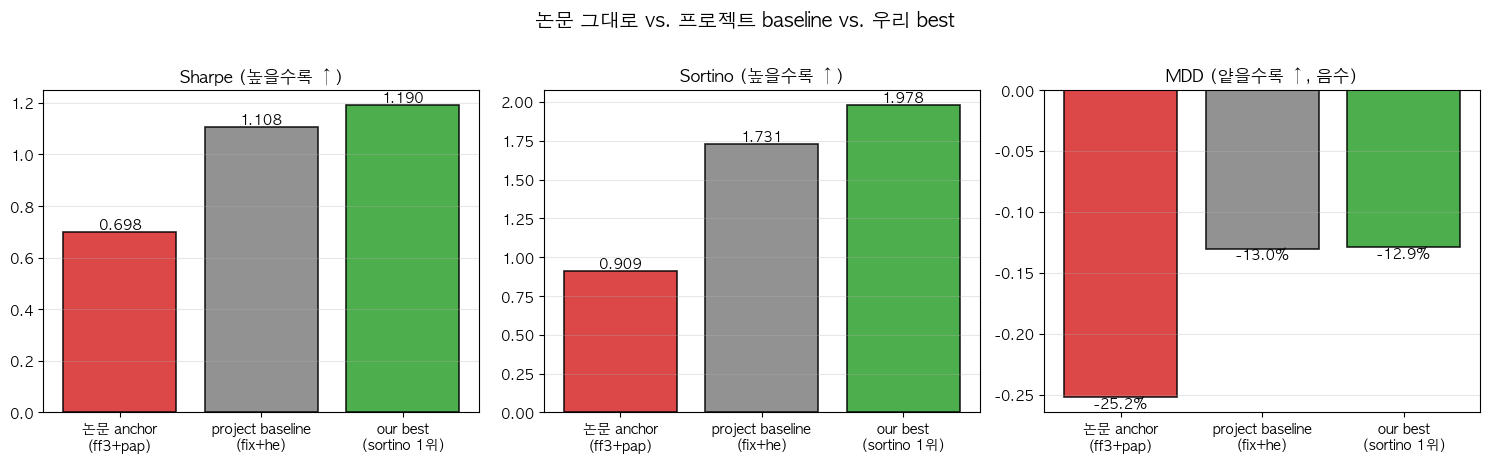

In [40]:
# ── A. 논문 anchor vs 우리 best/baseline 직접 비교 ────────────────
PAPER_ANCHOR = 'mcap_tr_mcap_ff3_pap'   # 논문 그대로
PROJ_BASE    = 'mcap_tr_mcap_fix_he'    # 프로젝트 baseline (q=fix, ω=he)

anchor = full[full['canonical']==PAPER_ANCHOR]
base   = full[full['canonical']==PROJ_BASE]
assert len(anchor)==1 and len(base)==1, '논문/프로젝트 baseline canonical 누락'
anchor = anchor.iloc[0]; base = base.iloc[0]

# 우리 best — K2-X50 교집합 composite 1위 (winner anchor와 일치)
# ⚠ 단순 sortino max는 sortino_ir 낮은 비-robust 후보가 잡힘 (예: paperctx_q_raw).
#    레짐 안정성까지 본 winner를 쓰는 게 슬롯 시각화 anchor와도 일관.
WINNER_NAME = 'eq_ls_eq_lam_pap'
best_match = full[full['canonical']==WINNER_NAME]
if len(best_match) == 0:
    # fallback: 단순 sortino 1위
    best = full.sort_values('sortino', ascending=False).iloc[0]
else:
    best = best_match.iloc[0]

print(f'논문 anchor : {anchor["canonical"]}  | sharpe {anchor["sharpe"]:.3f} / sortino {anchor["sortino"]:.3f} / mdd {anchor["mdd"]*100:.2f}%')
print(f'project base: {base["canonical"]}    | sharpe {base["sharpe"]:.3f} / sortino {base["sortino"]:.3f} / mdd {base["mdd"]*100:.2f}%')
print(f'우리 best   : {best["canonical"]}    | sharpe {best["sharpe"]:.3f} / sortino {best["sortino"]:.3f} / mdd {best["mdd"]*100:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['sharpe','sortino','mdd']
titles  = ['Sharpe (높을수록 ↑)','Sortino (높을수록 ↑)','MDD (얕을수록 ↑, 음수)']
labels  = ['논문 anchor\n(ff3+pap)','project baseline\n(fix+he)','our best\n(sortino 1위)']
colors  = ['#d62728', '#7f7f7f', '#2ca02c']

for ax, m, title in zip(axes, metrics, titles):
    vals = [anchor[m], base[m], best[m]]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v,
                f'{v:.3f}' if m!='mdd' else f'{v*100:.1f}%',
                ha='center', va='bottom' if v>=0 else 'top', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(0, color='black', linewidth=0.6)

fig.suptitle('논문 그대로 vs. 프로젝트 baseline vs. 우리 best',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'paper_anchor_top_compare.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)


## 차원 효과 플롯 함수

`plot_dim_effect(dim_short)`:
- 해당 차원의 pivot CSV 로드
- 3 subplots (sharpe, sortino, mdd) 생성
- 각 행 = 1개 line (다른 4 dim 고정)
- 색깔 = best_<dim>_by_sortino (그 조합의 sortino 최대 dim 값)
- 빈 값(NaN)은 line이 끊어짐 (특정 조합이 그 변형 미실험)

In [41]:
def plot_dim_effect(
    dim_short: str,
    show_legend: bool = True,
    line_alpha: float = 0.7,
    line_width: float = 1.3,
    legend_ncol: int = 4,
    legend_fontsize: int = 7,
    cmap_name: str = 'gist_ncar',
    save: bool = True,
):
    """
    한 슬롯 차원의 효과를 3-subplot 라인플롯으로 시각화.
    각 line = 다른 4 dim이 모두 고정된 조합 1개.
    각 line마다 고유 색깔 + 범례 라벨 (예: 'mcap_ls_eq_lam').

    Parameters
    ----------
    dim_short      : 'q' | 'prior' | 'p' | 'pw' | 'om'
    show_legend    : 조합별 범례 표시 여부
    line_alpha     : 라인 투명도 (조합 많을 때 낮추기)
    line_width     : 라인 굵기
    legend_ncol    : 범례 컬럼 수 (40~50개라 다중 컬럼 권장)
    legend_fontsize: 범례 폰트 크기
    cmap_name      : 색깔 맵 (gist_ncar = 최대 distinct, viridis = gradient)
    save           : PNG 저장 여부

    Note
    ----
    DIM_VALUE_ORDERS에 명시된 값만 x축에 포함. q에서 'none','capm','ff3'
    같은 비교군은 제외 — 비교 대상이 아니므로 시각적 노이즈만 만듦.
    """
    csv_path = OUT_DIR / f'pivot_by_{dim_short}.csv'
    df = pd.read_csv(csv_path)
    dim_label = DIM_LABELS[dim_short]

    # 다른 4 dim 컬럼 추출 (변수 dim 제외)
    short2full = {'prior': 'prior_s', 'p': 'p_s', 'pw': 'pw_s', 'q': 'q_s', 'om': 'om_s'}
    all_dims_full = ['prior_s', 'p_s', 'pw_s', 'q_s', 'om_s']
    fixed_full = [d for d in all_dims_full if d != short2full[dim_short]]

    metrics       = ['sharpe', 'sortino', 'mdd']
    metric_titles = ['Sharpe', 'Sortino', 'MDD (less negative = better)']
    order         = DIM_VALUE_ORDERS[dim_short]

    # 라인별 라벨 생성: 4 dim 값 underscore join
    df = df.copy()
    df['__label__'] = df[fixed_full].astype(str).agg('_'.join, axis=1)

    # 사전 필터링: 모든 메트릭에서 모든 값이 NaN인 행은 제외
    valid_mask = pd.Series(False, index=df.index)
    for m in metrics:
        cols = [f'{m}_{v}' for v in order if f'{m}_{v}' in df.columns]
        valid_mask |= df[cols].notna().any(axis=1)
    df = df[valid_mask].reset_index(drop=True)

    # 각 line에 고유색 (gist_ncar 또는 tab20 cycled)
    n_lines = len(df)
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / max(n_lines - 1, 1)) for i in range(n_lines)]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

    for ax, m, mtitle in zip(axes, metrics, metric_titles):
        cand_cols = [c for c in df.columns
                     if c.startswith(f'{m}_') and not c.endswith('_range')]
        # DIM_VALUE_ORDERS에 명시된 값만 그림 (그 외는 의도적 제외)
        ordered = [f'{m}_{v}' for v in order if f'{m}_{v}' in cand_cols]
        x_labels = [c.replace(f'{m}_', '') for c in ordered]
        x_pos = list(range(len(ordered)))

        for idx, (_, row) in enumerate(df.iterrows()):
            y = [row[c] if c in row.index and pd.notna(row[c]) else np.nan
                 for c in ordered]
            if all(np.isnan(v) for v in y):
                continue
            ax.plot(x_pos, y,
                    color=colors[idx],
                    alpha=line_alpha,
                    linewidth=line_width,
                    label=row['__label__'])

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=10)
        ax.set_title(mtitle, fontweight='bold', fontsize=12)
        ax.set_xlabel(f'{dim_label} value', fontsize=10)
        ax.set_ylabel(m.capitalize(), fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')

    # 공통 범례를 figure 하단 (3 subplot 모두 같은 라인이라 첫 subplot에서 handle 가져옴)
    if show_legend:
        h, l = axes[0].get_legend_handles_labels()
        n_rows = (len(l) + legend_ncol - 1) // legend_ncol
        fig.legend(
            h, l,
            loc='lower center',
            ncol=legend_ncol,
            fontsize=legend_fontsize,
            bbox_to_anchor=(0.5, -0.02 - 0.025 * n_rows),
            title=f'fixed (prior_p_pw_{",".join(d.replace("_s","") for d in fixed_full if d != "om_s")})  — total {n_lines} combos',
            title_fontsize=legend_fontsize + 1,
        )

    fig.suptitle(
        f'슬롯 차원 [{dim_label}] 효과 — 각 line = 다른 4 dim 고정 조합 ({n_lines}개)',
        fontsize=14, fontweight='bold', y=1.02
    )
    plt.tight_layout()

    if save:
        png = PLOT_DIR / f'slot_effect_{dim_short}.png'
        plt.savefig(png, dpi=120, bbox_inches='tight')
        print(f'✓ {png.relative_to(Path.cwd())}')
    plt.show()
    plt.close(fig)   # ← Jupyter 자동 재표시 방지: 명시적으로 닫음

print('✓ plot_dim_effect 정의 완료 (각 line = 고유 색 + 라벨, 1회 출력)')

# ── 논문 anchor 기준 1-슬롯 변경 효과 ─────────────────────────────
# plot_dim_effect()는 모든 4-dim 고정 조합 line(40~50개)을 그려 노이즈 큼.
# 본 함수는 논문 anchor (mcap_tr_mcap_ff3_pap)에서 ONE 슬롯만 변경한
# 결과를 두 anchor 시스템으로 깔끔하게 line 2개로만 보여줌:
#   🔴 논문 그대로  : prior=mcap, p=tr, pw=mcap, om=pap 고정 (q=ff3 ↔ 다른 q값)
#   🔵 LSTM 번역  : prior=mcap, p=ls, pw=mcap, om=pap 고정 (q=fix ↔ 다른 q값)
PAPER_ANCHOR_NAME = 'mcap_tr_mcap_ff3_pap'
LSTM_ANCHOR_NAME  = 'mcap_ls_mcap_fix_pap'

PAPER_SLOTS = {'prior_s':'mcap','p_s':'tr','pw_s':'mcap','q_s':'ff3','om_s':'pap'}
LSTM_SLOTS  = {'prior_s':'mcap','p_s':'ls','pw_s':'mcap','q_s':'fix','om_s':'pap'}

DIM_TO_COL_FULL = {'q':'q_s','prior':'prior_s','p':'p_s','pw':'pw_s','om':'om_s'}
DIM_X_VALUES_PAPER = {
    'q'    : ['ff3','fix','lam','raw','inv','vsp'],
    'prior': ['mcap','eq','rp'],
    'p'    : ['tr','ls'],
    'pw'   : ['mcap','eq','rp','volm'],
    'om'   : ['he','pap','rms'],
}

def plot_paper_anchor_effect(dim_short, save=True):
    # 논문 anchor 기준 dim_short 슬롯 1개만 변경한 trajectory.
    # red = paper-strict, blue = LSTM-translated.
    col      = DIM_TO_COL_FULL[dim_short]
    paper_v  = PAPER_SLOTS[col]
    values   = [v for v in DIM_X_VALUES_PAPER[dim_short] if v in full[col].dropna().unique()]
    metrics  = ['sharpe','sortino','mdd']

    paper_anchor = full[full['canonical']==PAPER_ANCHOR_NAME].iloc[0]

    def _series_for(anchor_slots, values):
        out = {m: [] for m in metrics}
        out['canonical'] = []
        for v in values:
            mask = (full[col]==v)
            for k, val in anchor_slots.items():
                if k != col:
                    mask &= (full[k]==val)
            sub = full[mask]
            if len(sub) == 0:
                for m in metrics: out[m].append(np.nan)
                out['canonical'].append(None)
            else:
                row = sub.iloc[0]
                for m in metrics: out[m].append(row[m])
                out['canonical'].append(row['canonical'])
        return out

    paper_series = _series_for(PAPER_SLOTS, values)
    lstm_series  = _series_for(LSTM_SLOTS,  values)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    metric_titles = ['Sharpe','Sortino','MDD']

    for ax, m, title in zip(axes, metrics, metric_titles):
        x = np.arange(len(values))

        ys_p = paper_series[m]
        ax.plot(x, ys_p, marker='o', markersize=12, linewidth=2.5,
                color='#d62728', label='논문 그대로 (p=tr, q=ff3 anchor)', zorder=3)
        for i, y in enumerate(ys_p):
            if pd.notna(y):
                v_str = f'{y:.3f}' if m!='mdd' else f'{y*100:.1f}%'
                ax.annotate(v_str, (i, y), textcoords='offset points',
                            xytext=(0, 12), ha='center', fontsize=8,
                            color='#d62728', fontweight='bold')

        ys_l = lstm_series[m]
        if any(pd.notna(y) for y in ys_l):
            ax.plot(x, ys_l, marker='s', markersize=10, linewidth=2.0,
                    color='#1f77b4', label='LSTM 번역 (p=ls, q=fix anchor)',
                    linestyle='--', alpha=0.9, zorder=2)
            for i, y in enumerate(ys_l):
                if pd.notna(y):
                    v_str = f'{y:.3f}' if m!='mdd' else f'{y*100:.1f}%'
                    ax.annotate(v_str, (i, y), textcoords='offset points',
                                xytext=(0, -16), ha='center', fontsize=8,
                                color='#1f77b4')

        anchor_label = (f'논문 anchor={paper_anchor[m]:.3f}'
                        if m!='mdd' else f'논문 anchor={paper_anchor[m]*100:.1f}%')
        ax.axhline(paper_anchor[m], color='gold', linestyle=':', linewidth=1.5,
                   alpha=0.7, label=anchor_label)

        if paper_v in values:
            p_idx = values.index(paper_v)
            ax.axvspan(p_idx-0.3, p_idx+0.3, color='gold', alpha=0.15, zorder=0)

        ax.set_xticks(x); ax.set_xticklabels(values, fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel(f'{DIM_LABELS[dim_short]} value (논문={paper_v})', fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(fontsize=8, loc='best')

    fig.suptitle(f'[{DIM_LABELS[dim_short]}] 1-슬롯 변경 효과 — 논문 anchor 기준\n'
                 f'🔴 = 4개 슬롯 paper 일치 / 🔵 = LSTM 번역 (p=ls, q=fix) / 황색 영역 = 논문이 선택한 값',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save:
        png = PLOT_DIR / f'paper_anchor_1slot_{dim_short}.png'
        plt.savefig(png, dpi=120, bbox_inches='tight')
        print(f'✓ {png.relative_to(Path.cwd())}')
    plt.show()
    plt.close(fig)

print('✓ plot_paper_anchor_effect 정의 완료 (🔴 paper-strict + 🔵 LSTM-translated 2 lines)')


# ── 논문 anchor + Winner anchor 1-슬롯 변경 통합 비교 ─────────────
# plot_paper_anchor_effect는 논문만, plot_anchor_compare는 두 anchor 통합.
WINNER_ANCHOR_NAME = 'eq_ls_eq_lam_pap'   # K2-X50 composite Top 1 (in-sample 168m)
WINNER_SLOTS = {'prior_s':'eq','p_s':'ls','pw_s':'eq','q_s':'lam','om_s':'pap'}

def plot_anchor_compare(dim_short, save=True):
    """
    🔴 논문 paper-strict / 🔵 LSTM-translated paper / 🟢 우리 winner
    세 trajectory를 한 figure (3 subplot: sharpe/sortino/mdd) 에 통합.

    각 line: anchor에서 dim_short 슬롯만 변경.
    🔴 sparse (paper 컨텍스트 실험 거의 없음) / 🟢 dense (winner는 matrix 안에 있음).
    """
    col      = DIM_TO_COL_FULL[dim_short]
    paper_v  = PAPER_SLOTS[col]
    winner_v = WINNER_SLOTS[col]
    values   = [v for v in DIM_X_VALUES_PAPER[dim_short] if v in full[col].dropna().unique()]
    metrics  = ['sharpe','sortino','mdd']

    paper_anchor  = full[full['canonical']==PAPER_ANCHOR_NAME].iloc[0]
    winner_anchor = full[full['canonical']==WINNER_ANCHOR_NAME].iloc[0]

    def _series_for(anchor_slots, values):
        out = {m: [] for m in metrics}
        for v in values:
            mask = (full[col]==v)
            for k, val in anchor_slots.items():
                if k != col:
                    mask &= (full[k]==val)
            sub = full[mask]
            if len(sub) == 0:
                for m in metrics: out[m].append(np.nan)
            else:
                row = sub.iloc[0]
                for m in metrics: out[m].append(row[m])
        return out

    paper_series  = _series_for(PAPER_SLOTS,  values)
    lstm_series   = _series_for(LSTM_SLOTS,   values)
    winner_series = _series_for(WINNER_SLOTS, values)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    metric_titles = ['Sharpe','Sortino','MDD']

    for ax, m, title in zip(axes, metrics, metric_titles):
        x = np.arange(len(values))

        # 🔴 paper-strict
        ys_p = paper_series[m]
        ax.plot(x, ys_p, marker='o', markersize=11, linewidth=2.2,
                color='#d62728', label='논문 그대로 (p=tr, q=ff3)', zorder=3)
        for i, y in enumerate(ys_p):
            if pd.notna(y):
                vs = f'{y:.3f}' if m!='mdd' else f'{y*100:.1f}%'
                ax.annotate(vs, (i, y), textcoords='offset points',
                            xytext=(0, 11), ha='center', fontsize=7,
                            color='#d62728', fontweight='bold')

        # 🔵 LSTM-translated paper
        ys_l = lstm_series[m]
        if any(pd.notna(y) for y in ys_l):
            ax.plot(x, ys_l, marker='s', markersize=9, linewidth=1.8,
                    color='#1f77b4', label='LSTM 번역 (p=ls, q=fix)',
                    linestyle='--', alpha=0.85, zorder=2)
            for i, y in enumerate(ys_l):
                if pd.notna(y):
                    vs = f'{y:.3f}' if m!='mdd' else f'{y*100:.1f}%'
                    ax.annotate(vs, (i, y), textcoords='offset points',
                                xytext=(8, 0), ha='left', fontsize=7,
                                color='#1f77b4')

        # 🟢 winner-anchored
        ys_w = winner_series[m]
        ax.plot(x, ys_w, marker='*', markersize=14, linewidth=2.6,
                color='#2ca02c', label=f'winner ({WINNER_ANCHOR_NAME})', zorder=4)
        for i, y in enumerate(ys_w):
            if pd.notna(y):
                vs = f'{y:.3f}' if m!='mdd' else f'{y*100:.1f}%'
                ax.annotate(vs, (i, y), textcoords='offset points',
                            xytext=(0, -15), ha='center', fontsize=7,
                            color='#2ca02c', fontweight='bold')

        # reference: 논문 anchor 가로선
        ax.axhline(paper_anchor[m], color='gold', linestyle=':', linewidth=1.3,
                   alpha=0.7, label=(f'논문 anchor={paper_anchor[m]:.3f}'
                                     if m!='mdd' else f'논문 anchor={paper_anchor[m]*100:.1f}%'))

        # winner의 슬롯값 위치 강조
        if winner_v in values:
            w_idx = values.index(winner_v)
            ax.axvspan(w_idx-0.35, w_idx+0.35, color='#2ca02c', alpha=0.10, zorder=0)

        ax.set_xticks(x); ax.set_xticklabels(values, fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel(f'{DIM_LABELS[dim_short]} value '
                      f'(논문={paper_v} · winner={winner_v})', fontsize=9)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(fontsize=7.5, loc='best')

    fig.suptitle(f'[{DIM_LABELS[dim_short]}] 1-슬롯 변경 효과 — 논문 vs LSTM 번역 vs 우리 winner\n'
                 f'🔴 prior=mcap,p=tr,pw=mcap,om=pap / 🔵 prior=mcap,p=ls,pw=mcap,om=pap,q=fix / '
                 f'🟢 prior=eq,p=ls,pw=eq,q=lam,om=pap (winner) · 녹색 영역 = winner의 슬롯값',
                 fontsize=11.5, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save:
        png = PLOT_DIR / f'anchor_compare_1slot_{dim_short}.png'
        plt.savefig(png, dpi=120, bbox_inches='tight')
        print(f'✓ {png.relative_to(Path.cwd())}')
    plt.show()
    plt.close(fig)

print('✓ plot_anchor_compare 정의 완료 (🔴 paper / 🔵 LSTM / 🟢 winner — 3 lines 통합)')


✓ plot_dim_effect 정의 완료 (각 line = 고유 색 + 라벨, 1회 출력)
✓ plot_paper_anchor_effect 정의 완료 (🔴 paper-strict + 🔵 LSTM-translated 2 lines)
✓ plot_anchor_compare 정의 완료 (🔴 paper / 🔵 LSTM / 🟢 winner — 3 lines 통합)


## q 차원 효과 — 논문 vs Winner 1-슬롯 변경 비교

세 anchor 시스템에서 q만 변경했을 때 trajectory 통합 비교:
- **🔴 논문 그대로** (prior=mcap, p=tr, pw=mcap, om=pap, q=ff3 anchor): paper-strict, sparse
- **🔵 LSTM 번역** (p=ls + q=fix anchor, 나머지 paper): paper의 LSTM 변환
- **🟢 우리 winner** (`eq_ls_eq_lam_pap` = prior=eq, p=ls, pw=eq, q=lam, om=pap): K2-X50 composite Top 1, q ∈ {fix, lam, raw, inv, vsp} 5점 모두 dense

→ **녹색 별표가 빨간 점보다 위**: winner anchor가 논문보다 모든 q 값에서 우월.
→ **녹색 라인의 slope**: winner 컨텍스트(prior=eq, pw=eq)에서 q를 바꿀 때 marginal effect.

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_q.png


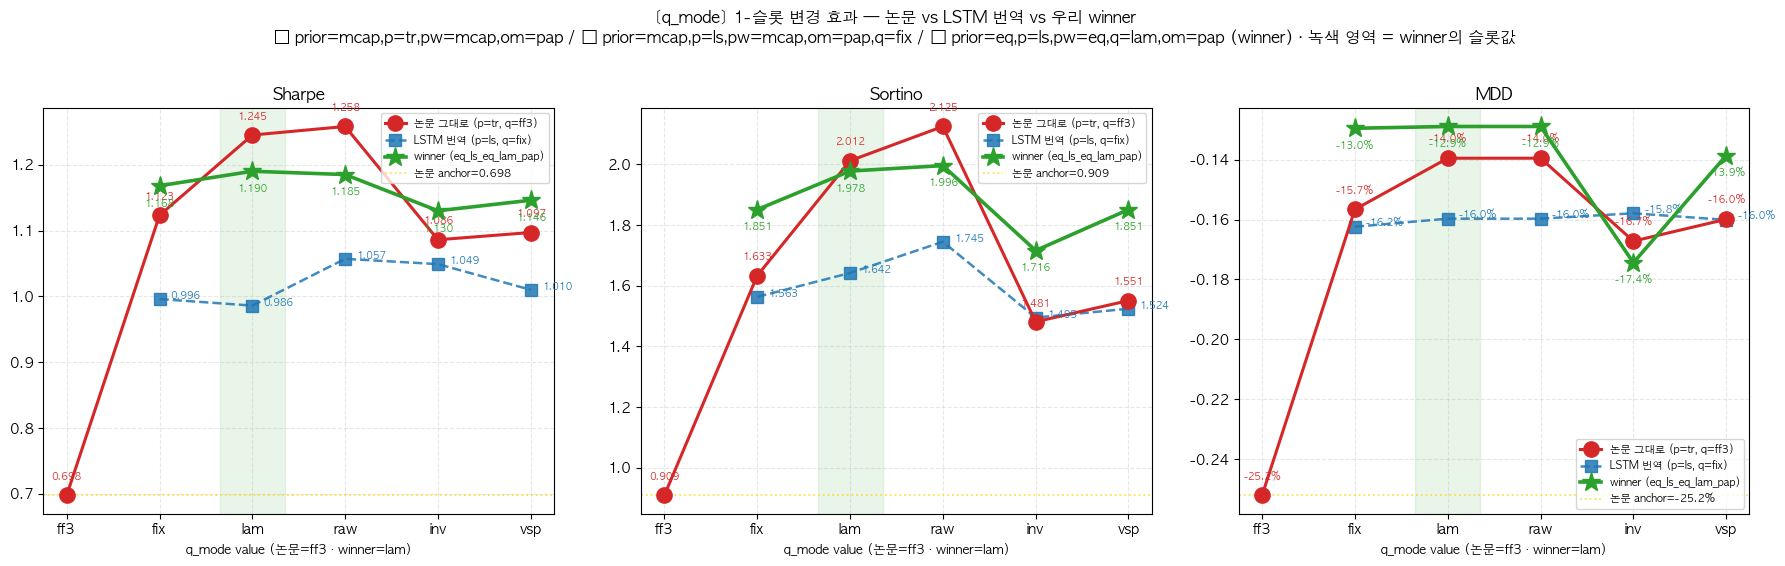

In [42]:
plot_anchor_compare('q')

## prior 차원 효과 — 논문 vs Winner 1-슬롯 변경 비교

- **🔴 논문 그대로**: prior=mcap (anchor) 1점만 — 다른 prior 실험 없음
- **🔵 LSTM 번역**: 데이터 거의 없음
- **🟢 winner anchor**: p=ls, pw=eq, q=lam, om=pap 고정, prior ∈ {mcap, eq, rp} 3점 dense

→ winner 라인 slope = "winner 슬롯 조합에서 prior 변경의 효과". eq 선택 근거 시각화.

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_prior.png


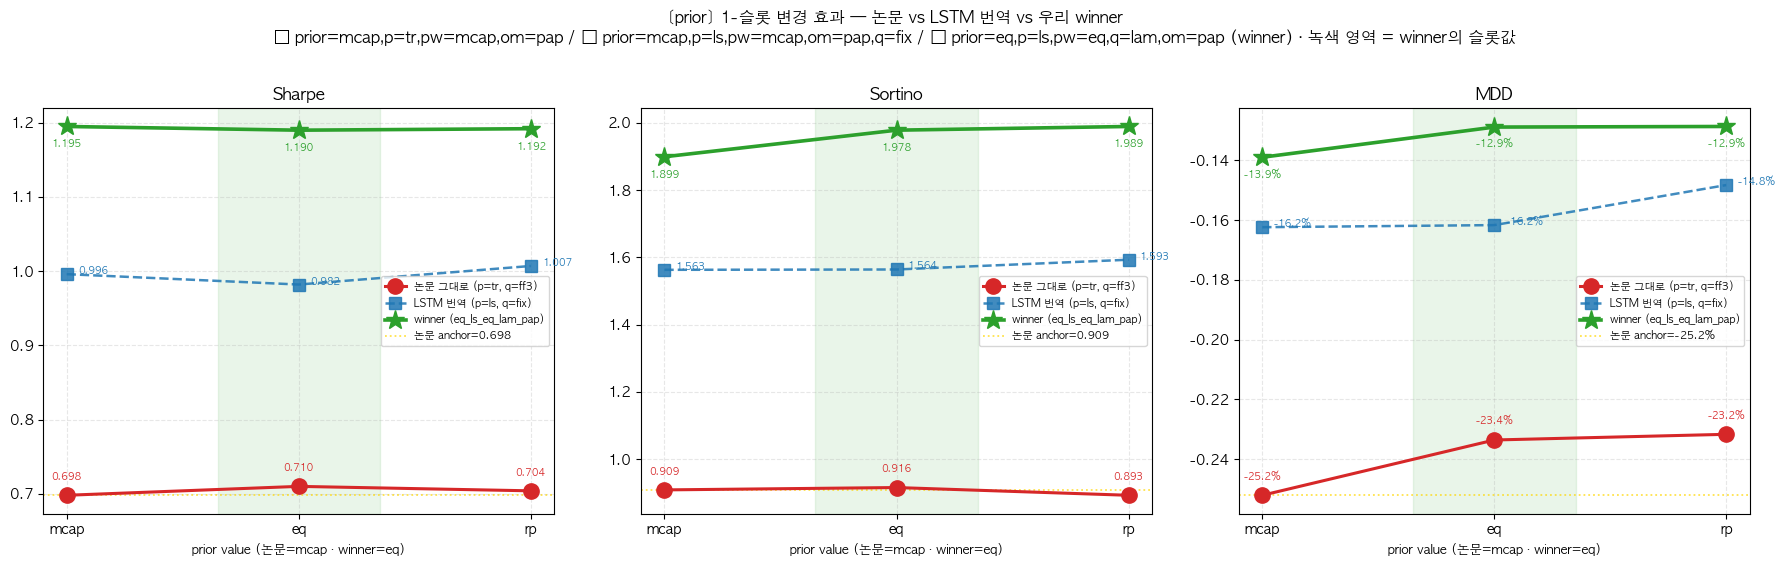

In [43]:
plot_anchor_compare('prior')

## p 차원 효과 — P-mode (P 분류용 σ 출처) · 논문 vs Winner 1-슬롯 변경 비교

p ∈ {`tr` (trailing 21d 실현변동성) / `ls` (LSTM 앙상블 예측)}.

- **🔴 논문 그대로** (prior=mcap, pw=mcap, q=ff3, om=pap): p=tr (anchor) 1점만 — q=ff3 + p=ls 조합 미실험
- **🔵 LSTM 번역** (prior=mcap, pw=mcap, q=fix, om=pap): p=tr (1.633) ↔ p=ls (1.563) **둘 다 존재** ← 이 줄이 p dim의 핵심
- **🟢 winner** (prior=eq, pw=eq, q=lam, om=pap): p=ls (anchor) 1점만 — winner를 trailing으로 돌린 적 없음

→ **🔵 라인의 tr→ls slope = "LSTM이 trailing 대비 가져오는 lift"** (paper context).
→ 발견: 이 컨텍스트에선 LSTM이 trailing보다 sortino 0.07 *낮음*. LSTM의 진짜 lift는 winner의 다른 슬롯(prior=eq, pw=eq, q=lam)과 결합됐을 때만 발휘됨.


✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_p.png


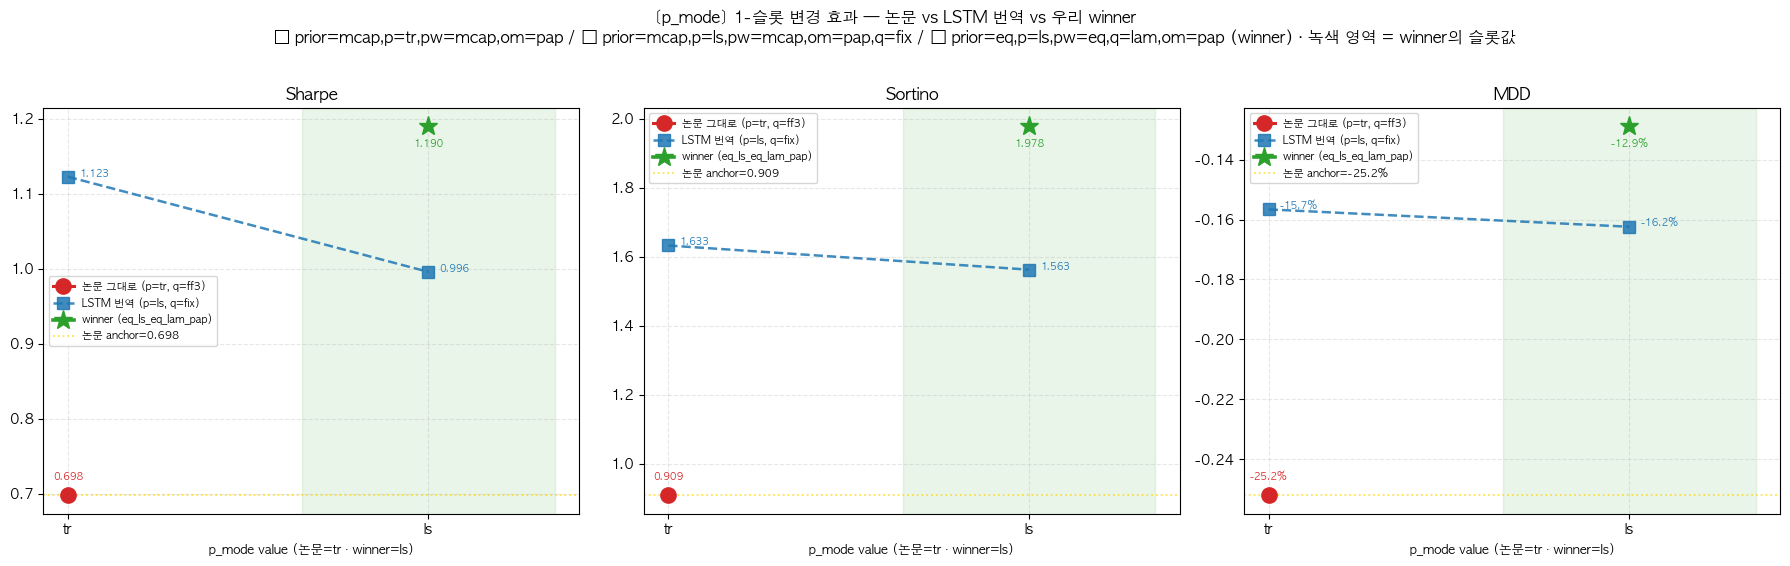

In [44]:
plot_anchor_compare('p')

## pw 차원 효과 — 논문 vs Winner 1-슬롯 변경 비교

- **🔴 논문 그대로**: pw=mcap (anchor) 1점만
- **🟢 winner anchor**: prior=eq, p=ls, q=lam, om=pap 고정, pw ∈ {mcap, eq, rp} 3점 dense

→ winner 라인은 pw=eq에서 sortino_full 1.978 정점. mcap·rp로 바꾸면 어느 정도 떨어지는지 한눈에 보임.

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_pw.png


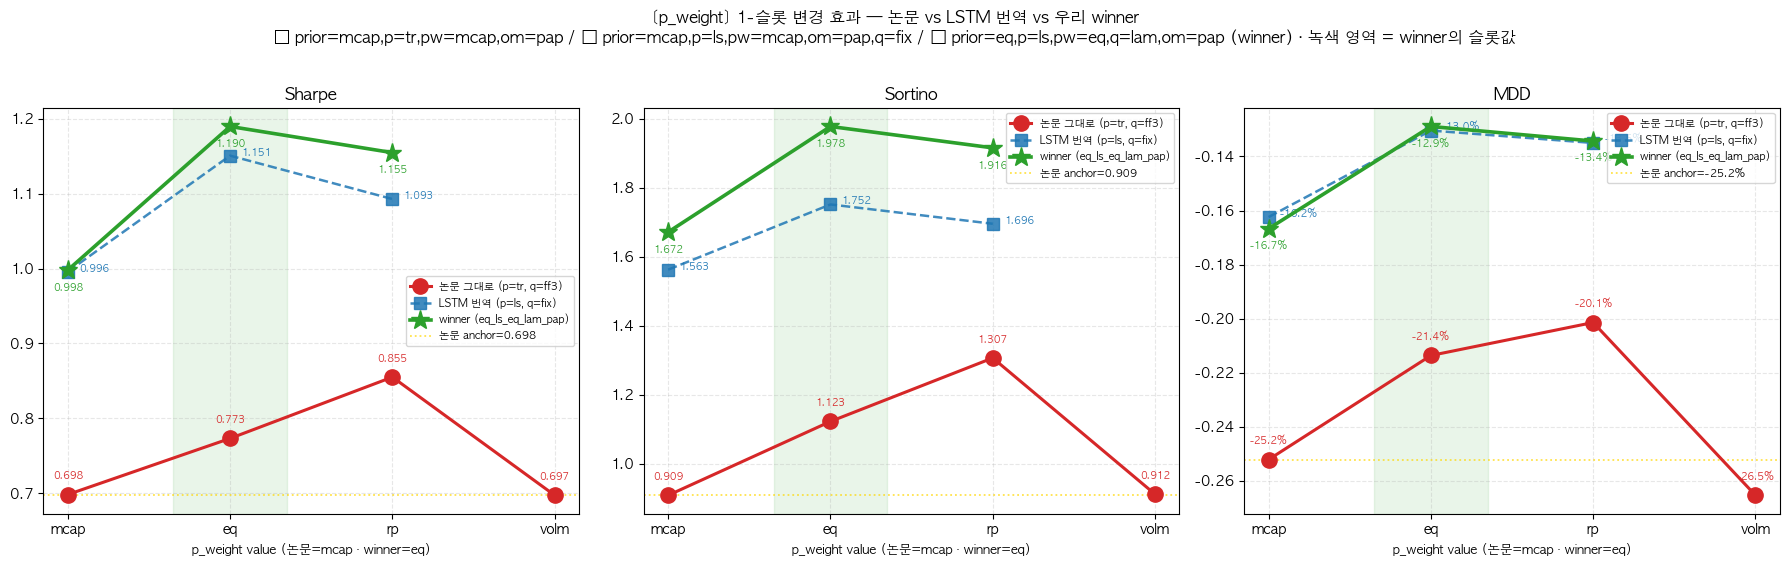

In [45]:
plot_anchor_compare('pw')

## om 차원 효과 — 논문 vs Winner 1-슬롯 변경 비교

- **🔴 논문 그대로**: om=he, om=pap 2점 (rms는 q=ff3 컨텍스트로 미실험)
- **🟢 winner anchor**: prior=eq, p=ls, pw=eq, q=lam 고정, om ∈ {he, pap, rms} 3점 dense

→ 빨간/녹색 라인의 he→pap slope를 비교: 두 컨텍스트 모두에서 pap가 he보다 우위인지 일관성 점검.

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_om.png


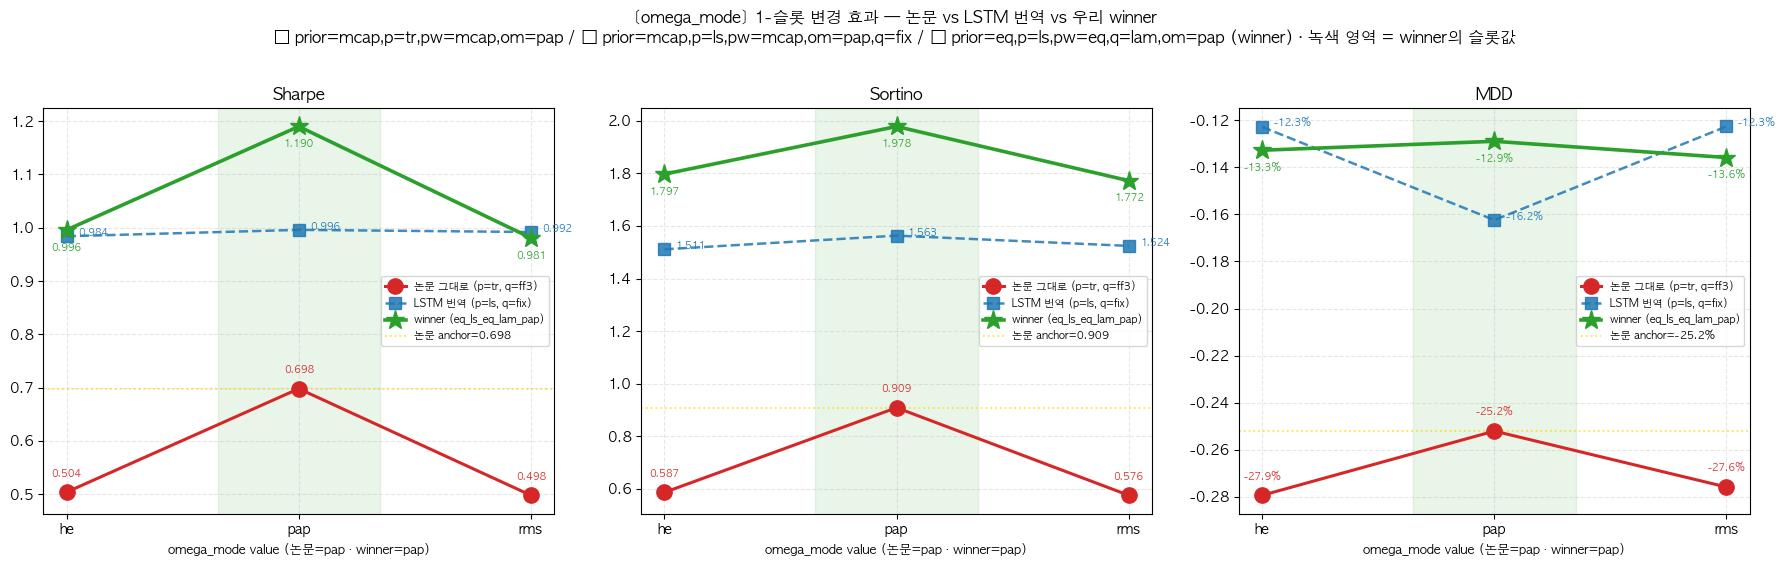

In [46]:
plot_anchor_compare('om')

## 한 번에 모두 그리기 (편의용)

5개 차원 모두 한 번에 다시 그리고 싶을 때.

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_q.png


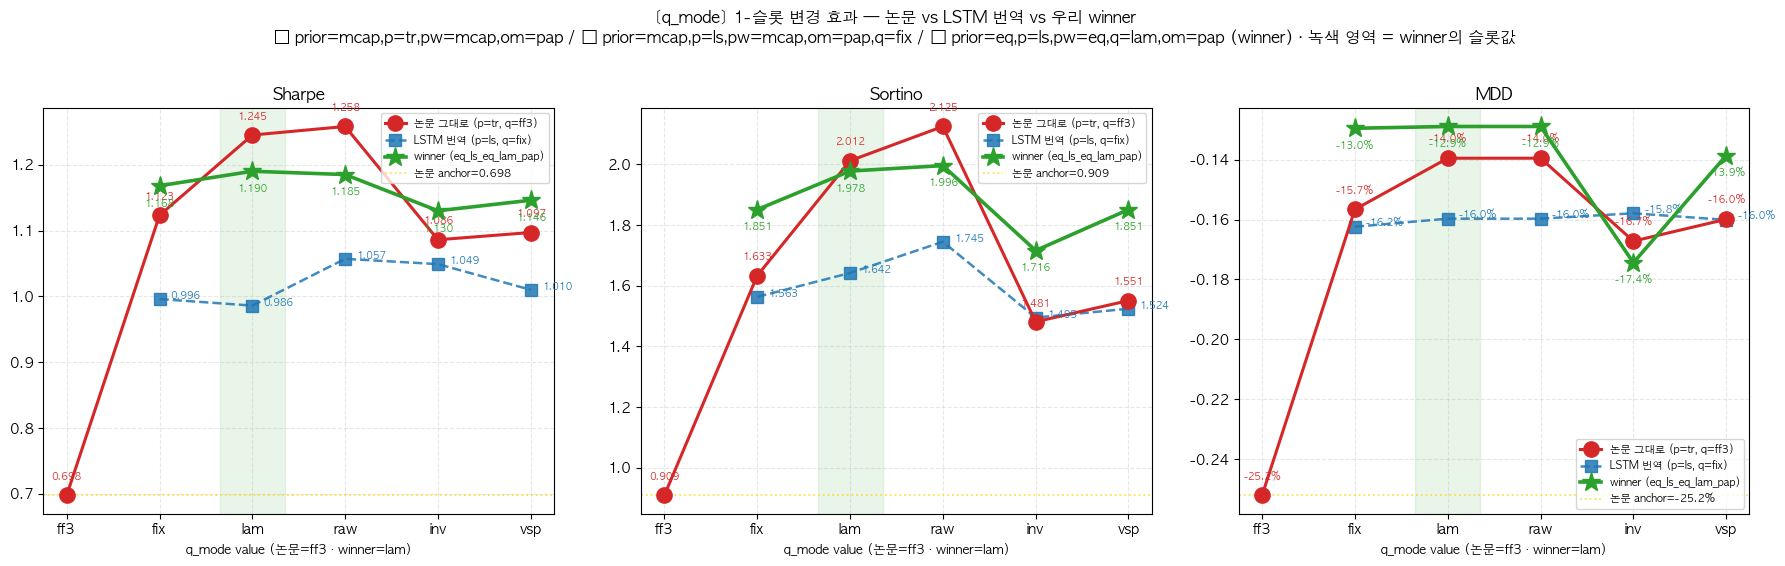

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_prior.png


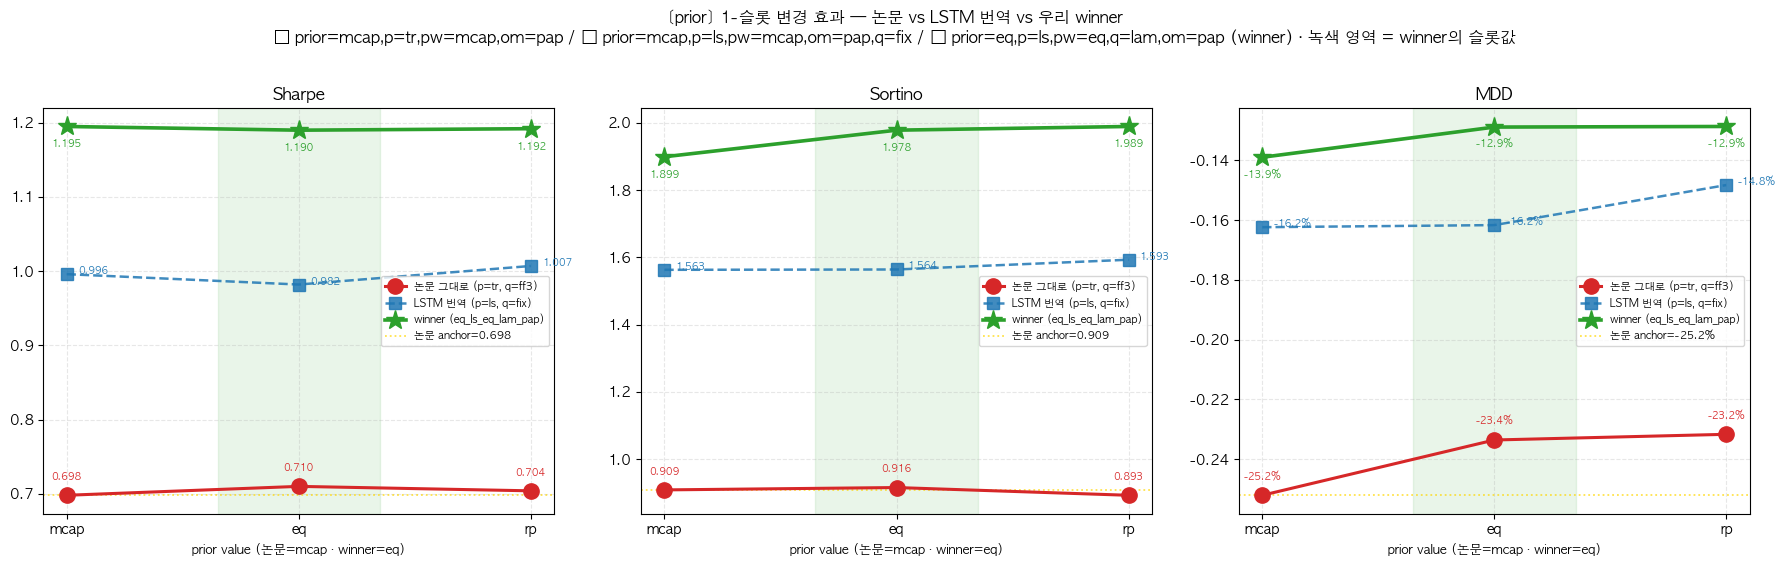

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_p.png


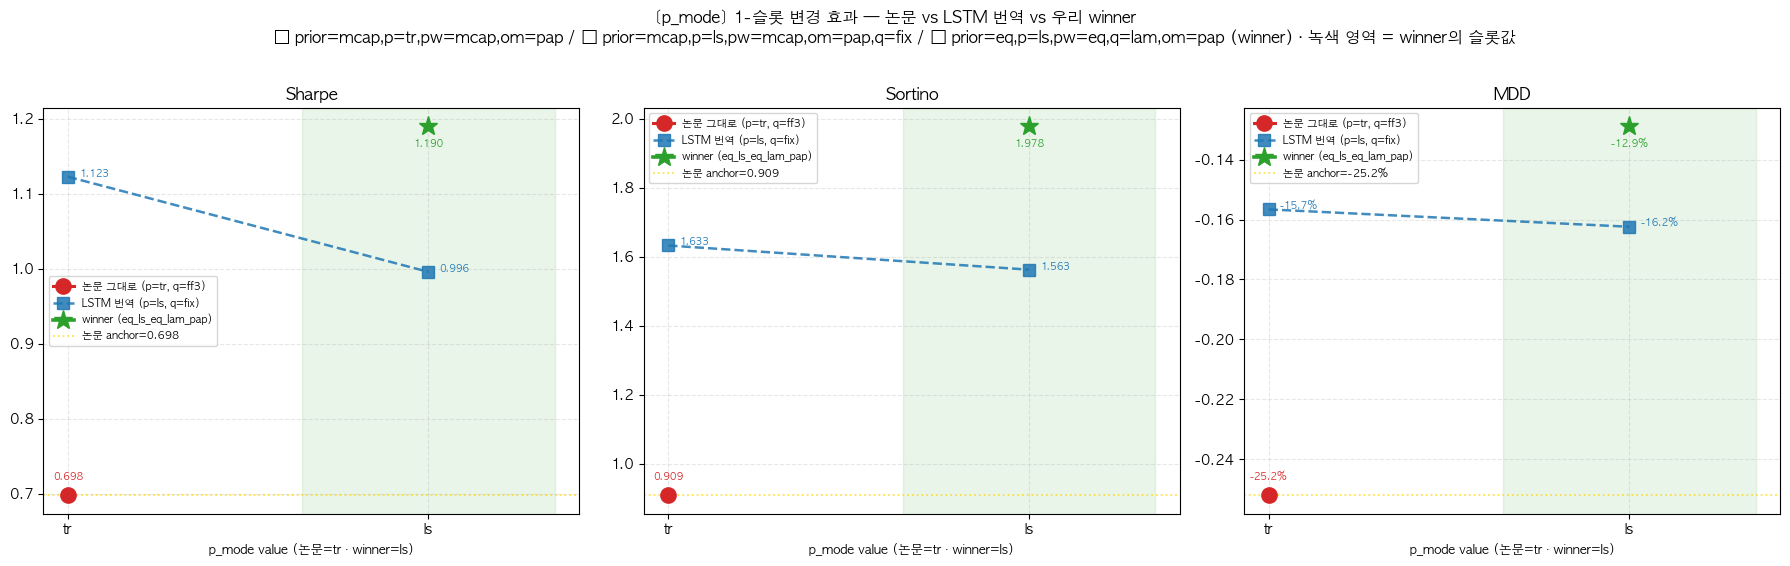

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_pw.png


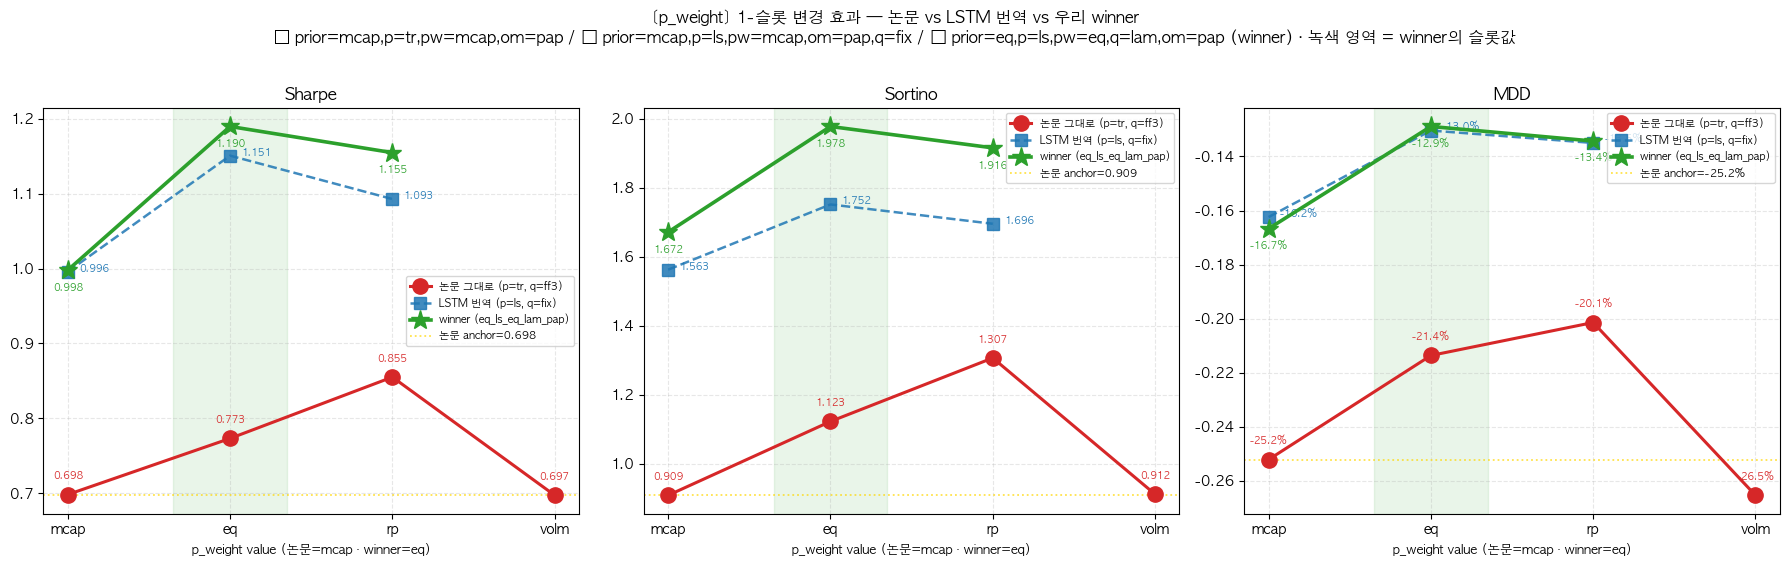

✓ outputs/99_analyze/slot_effects/anchor_compare_1slot_om.png


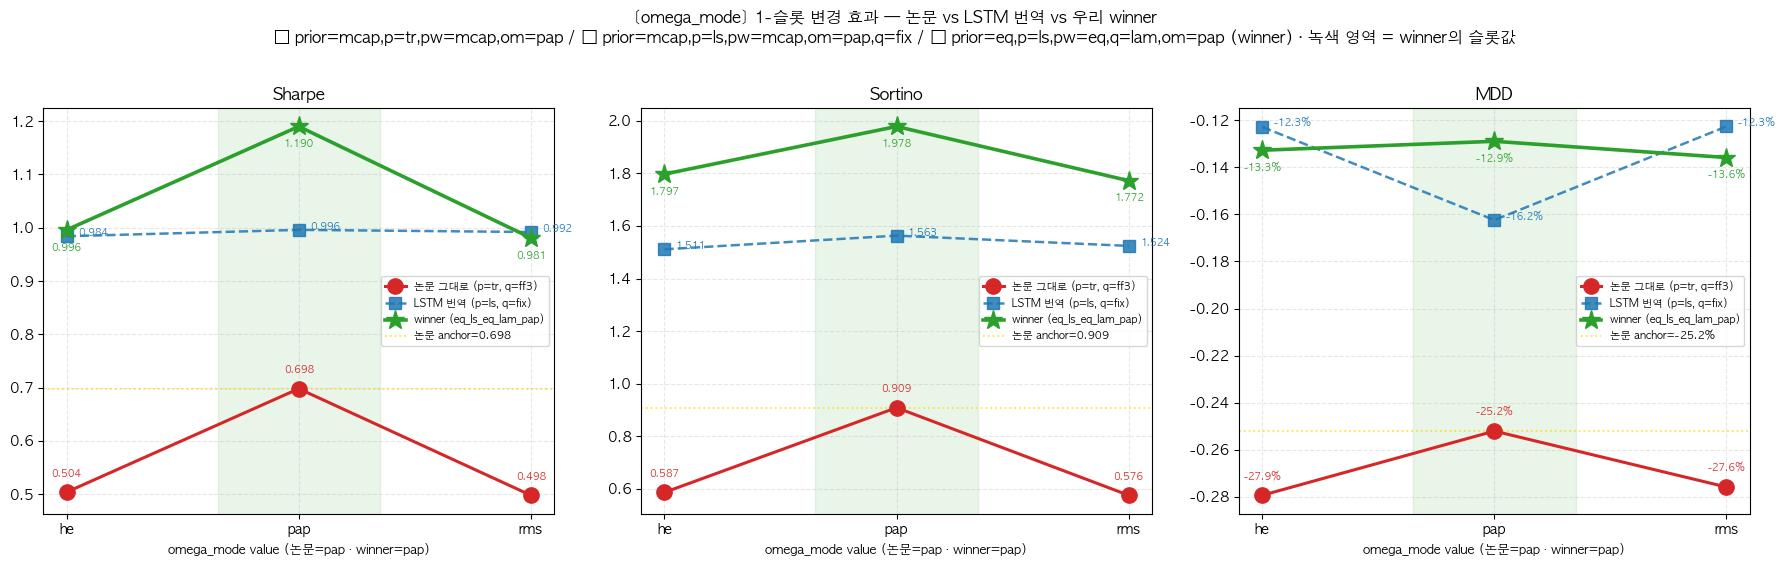


✓ 5개 차원 모두 anchor_compare 통합


In [47]:
# 5개 차원 모두 anchor_compare 통합 (논문 + LSTM 번역 + winner)
for dim_short in ['q','prior','p','pw','om']:
    plot_anchor_compare(dim_short)
print('\n✓ 5개 차원 모두 anchor_compare 통합')
